# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



Question 1:
This dataset examines how social media use impacts the mental health of teenagers, covering daily habits such as social media screen time, sleep patterns, stress levels, anxiety, and physical activity.

While the data appears to be synthetic — with limited documentation about its origins — it stands out from other datasets because of its focused scope and clean structure. Unlike broader datasets that cover all age groups, this one specifically targets teenagers and narrows the platform focus to Instagram, TikTok, or both, which makes the analysis more targeted and meaningful.

I chose this dataset for several reasons. First, I have a genuine concern about mental health as a growing healthcare issue, particularly among young people. Second, I saw it as an opportunity to learn about both the subject matter and the data science techniques used to study it. Finally, this topic feels personally relevant to me — as someone who also uses social media, I find myself thinking about its effects on my own habits and wellbeing.

The dataset contains 1,200 records and 13 features:

age — the teenager's age, ranging from 13 to 19 years old
gender — male or female
daily_social_media_hours — number of hours spent on social media per day 
platform_usage — the platform used: Instagram, TikTok, or Both
sleep_hours — average hours of sleep per night 
screen_time_before_sleep — hours of screen time before sleeping
academic_performance — GPA or academic score
physical_activity — hours of physical activity per day
social_interaction_level — level of social interaction: low, medium, or high
stress_level — stress score on a numeric scale
anxiety_level — anxiety score on a numeric scale
addiction_level — social media addiction score on a numeric scale
depression_label — binary indicator of depression (0 = no, 1 = yes)


Question 2 :
1. Which platform (Instagram, TikTok, or Both) is associated with the highest average stress and anxiety levels?
2. Is there a difference in average sleep hours between teenagers with high vs. low social media usage?
3. What percentage of teenagers who use social media more than 3 hours/day report poor mental health?
4. How does physical activity level relate to anxiety and stress scores across different platforms?
5. Which age group of teenagers is most affected by social media in terms of sleep deprivation and stress?

Question 3:

1. Which platform (Instagram, TikTok, or Both) is associated with the highest average stress and anxiety levels?

In [1]:
import pandas as pd
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [2]:
df.groupby('platform_usage')[["stress_level", "anxiety_level"]].max()

,stress_level,anxiety_level
platform_usage,,
Both,10,10
Instagram,10,10
TikTok,10,10


In [3]:
df_platform = df.groupby('platform_usage')[["stress_level", "anxiety_level"]].mean()
df_platform

,stress_level,anxiety_level
platform_usage,,
Both,5.549872,5.488491
Instagram,5.498783,5.669100
TikTok,5.288945,5.748744


(array([0, 1, 2]),
 [Text(0, 0, 'Both'), Text(1, 0, 'Instagram'), Text(2, 0, 'TikTok')])

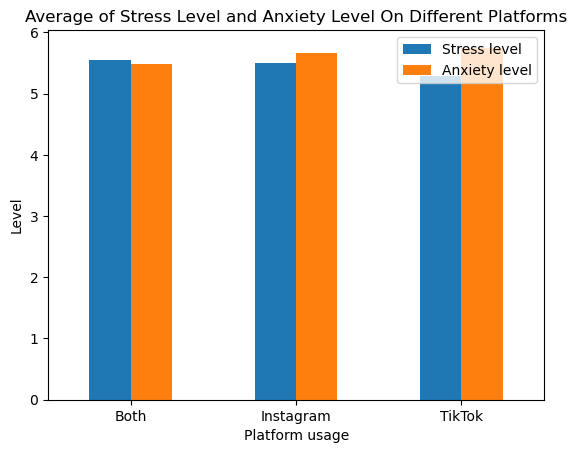

In [22]:
import matplotlib.pyplot as plt
df_platform.plot(kind = "bar")
plt.title('Average of Stress Level and Anxiety Level On Different Platforms')
plt.legend(['Stress level', 'Anxiety level'])
plt.xlabel('Platform usage')
plt.ylabel('Level')
plt.xticks(rotation = 0)


Overall, there is not much difference in anxiety and stress levels across Instagram users, TikTok users, and those who use both platforms. TikTok users do show a slightly higher anxiety level (5.7) compared to the others, however their stress level appears to be marginally lower(5.2).

2. Is there a difference in average sleep hours between teenagers with high vs. low social media usage?

In [5]:
df['sleep_hours'].describe()

count    1200.000000
mean        6.449417
std         1.442677
min         4.000000
25%         5.200000
50%         6.500000
75%         7.600000
max         9.000000
Name: sleep_hours, dtype: float64

In [6]:
df_sleepGroup = pd.cut(df['sleep_hours'],bins=[0,6.5,9], labels = ["Low","High"])
df_sleepGroup

0       High
1       High
2       High
3       High
4        Low
        ... 
1195    High
1196    High
1197    High
1198    High
1199     Low
Name: sleep_hours, Length: 1200, dtype: category
Categories (2, object): ['Low' < 'High']

In [7]:
df_sleep = df['daily_social_media_hours'].groupby(df_sleepGroup,observed = True).mean()
df_sleep

sleep_hours
Low     4.534466
High    4.539003
Name: daily_social_media_hours, dtype: float64

(array([0, 1]), [Text(0, 0, 'Low'), Text(1, 0, 'High')])

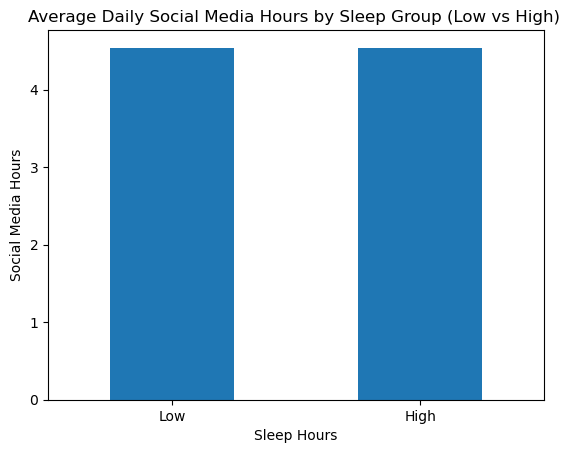

In [23]:
df_sleep.plot(kind = "bar")
plt.title('Average Daily Social Media Hours by Sleep Group (Low vs High) ')
plt.ylabel('Social Media Hours')
plt.xlabel('Sleep Hours')
plt.xticks(rotation = 0)

According to the data, there is no significant difference in daily social media usage between teenagers who sleep less and those who sleep more. Both groups average approximately 4.5 hours of social media use per day, suggesting that sleep duration has little to no relationship with social media consumption in this dataset. 

3. What percentage of teenagers who use social media more than 3 hours/day report poor mental health?

In [9]:
high_usage = df[df['daily_social_media_hours'] >= 3]
low_usage = df[df['daily_social_media_hours'] < 3]
high_usage


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,13,male,7.8,TikTok,5.9,1.5,3.31,1.9,high,10,1,10,0
1193,13,female,7.2,Instagram,8.1,2.1,2.52,0.4,medium,3,3,7,0
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [10]:
low_usage

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0
16,13,male,1.5,Both,4.2,1.4,2.59,0.5,high,4,5,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187,18,male,2.0,Instagram,8.9,0.8,2.96,0.5,medium,6,2,2,0
1189,14,female,1.6,TikTok,4.8,2.4,2.97,1.9,low,9,9,10,0
1194,17,male,2.0,Both,4.5,1.7,2.65,0.0,medium,9,4,2,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0


In [11]:
high_pct = high_usage['depression_label'].value_counts(normalize=True).get(1, 0) * 100
low_pct = low_usage['depression_label'].value_counts(normalize=True).get(1, 0) * 100

In [12]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

Text(0.5, 0, 'Social Media users')

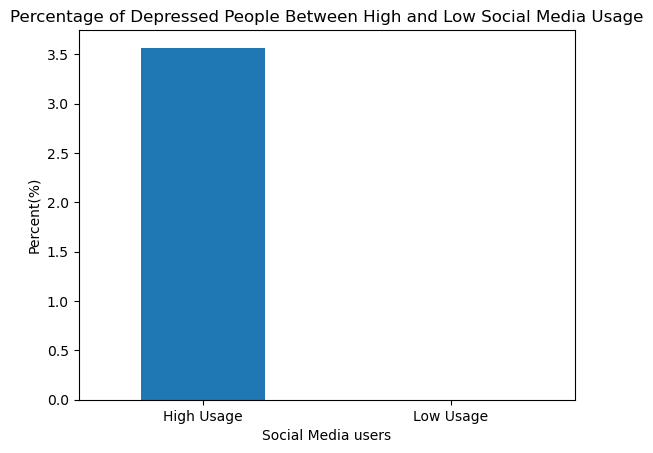

In [24]:
import matplotlib.pyplot as plt
depression_pct = pd.Series({
    'High Usage': high_pct,
    'Low Usage': low_pct
})

depression_pct.plot(kind='bar')
plt.title('Percentage of Depressed People Between High and Low Social Media Usage')
plt.xticks(rotation = 0)
plt.ylabel("Percent(%)")
plt.xlabel("Social Media users")

In [14]:
df.groupby('depression_label')['daily_social_media_hours'].mean()

depression_label
0    4.478785
1    6.719355
Name: daily_social_media_hours, dtype: float64

According to the data, teenagers who use social media more than 3 hours per day are 3.5% more likely to experience depression compared to those who use it less. Furthermore, teenagers diagnosed with depression spend an average of 6.7 hours per day on social media, which is approximately 2.2 hours more than those without depression (4.5 hours). This suggests that excessive social media usage, particularly above 6 hours per day, may be associated with a higher risk of depression among teenagers

4. Which age group of teenagers has the highest addiction level to social media?

In [15]:
df_age = pd.cut(df['age'], bins=[13, 15, 17, 19], labels = ["Early Teens", "Mid Teens", "Late Teens"])

In [16]:
df_agegroup =df.groupby(df_age, observed=True)['addiction_level'].mean()


Text(0, 0.5, 'Addiction level')

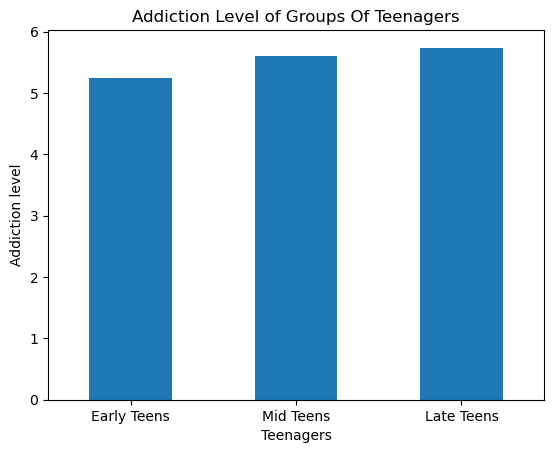

In [25]:
df_agegroup.plot(kind='bar')
plt.title('Addiction Level of Groups Of Teenagers')
plt.xticks(rotation = 0)
plt.xlabel("Teenagers")
plt.ylabel("Addiction level")
plt.show()

According to the data, late teenagers (18–19 years old) have the highest average addiction level to social media at 5.74, followed by mid teenagers (16–17 years old) at 5.60, and early teenagers (13–15 years old) at 5.25. This suggests that social media addiction tends to increase with age among teenagers.


5. Do teenagers with high social interaction level have lower stress and anxiety?

In [18]:
df['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [19]:
df_social = df.groupby('social_interaction_level', observed=True)[['stress_level','anxiety_level']].mean()
df_social

,stress_level,anxiety_level
social_interaction_level,,
high,5.512195,5.704607
low,5.349398,5.525301
medium,5.483173,5.687500


Text(0, 0.5, 'Average level')

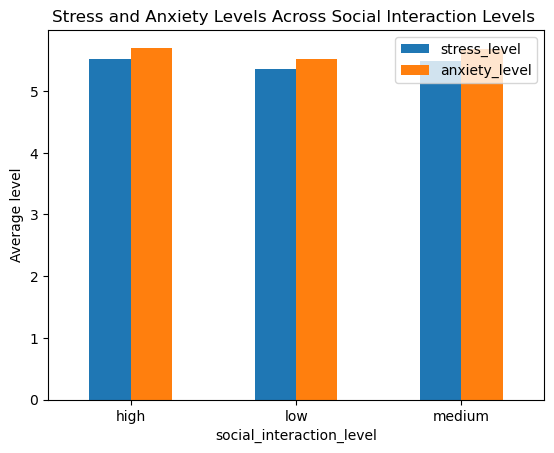

In [20]:
df_social.plot(kind='bar')
plt.title('Stress and Anxiety Levels Across Social Interaction Levels ')
plt.xticks(rotation = 0)
plt.ylabel("Average level")

Teenagers with a higher social interaction level tend to have slightly higher stress and anxiety levels compared to those with low social interaction. Specifically, teenagers with high social interaction recorded an average stress level of 5.51 and anxiety level of 5.70, compared to those with low social interaction at 5.35 and 5.53 respectively. 